In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from pathlib import Path
from PIL import Image

In [3]:

def find_project_root(
    start: str | Path = ".",
    *,
    marker: str = "pictures",
    required_subpath: str = "pictures/pictures_in",
    max_up: int = 10,
) -> Path:
    """
    Find a root directory by walking upwards until `required_subpath` exists.
    """
    p = Path(start).resolve()
    for _ in range(max_up + 1):
        if (p / required_subpath).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Cannot find project root from {Path(start).resolve()} "
        f"(missing {required_subpath}). "
        f"Try setting root=Path('...') to your repo root."
    )
def to_float01(img: np.ndarray) -> np.ndarray:
    x = img.astype(np.float64)
    if np.issubdtype(img.dtype, np.integer):
        x /= 255.0
    else:
        if x.max() > 1.0:
            x /= 255.0
    return np.clip(x, 0.0, 1.0)

def to_gray_luminance(img: np.ndarray) -> np.ndarray:
    x = to_float01(img)
    if x.ndim == 2:
        return x
    R = x[..., 0]
    G = x[..., 1]
    B = x[..., 2]
    return 0.2126 * R + 0.7152 * G + 0.0722 * B

def band_stats(gray: np.ndarray, n_bins: int = 64, connectivity: int = 2):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2

    pixel_counts = []
    max_cc_areas = []
    num_ccs = []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        band = (gray >= lo) & (gray < hi)

        pixel_counts.append(int(band.sum()))

        lab = label(band, connectivity=connectivity)
        props = regionprops(lab)
        areas = [r.area for r in props]

        max_cc_areas.append(max(areas) if areas else 0)
        num_ccs.append(len(areas))

    return centers, edges, np.array(pixel_counts), np.array(max_cc_areas), np.array(num_ccs)

def plot_band_stats(gray: np.ndarray, n_bins: int = 64):
    centers, edges, pixel_counts, max_cc_areas, num_ccs = band_stats(gray, n_bins=n_bins)

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

    axes[0].plot(centers, pixel_counts, linewidth=2)
    axes[0].set_ylabel("pixel count")
    axes[0].set_title("Pixels per gray band")

    axes[1].plot(centers, max_cc_areas, linewidth=2)
    axes[1].set_ylabel("max CC area")
    axes[1].set_title("Largest connected component per gray band")

    axes[2].plot(centers, num_ccs, linewidth=2)
    axes[2].set_ylabel("num CCs")
    axes[2].set_xlabel("gray band center (0=dark, 1=bright)")
    axes[2].set_title("Number of connected components per gray band")

    for ax in axes:
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    return centers, edges, pixel_counts, max_cc_areas, num_ccs

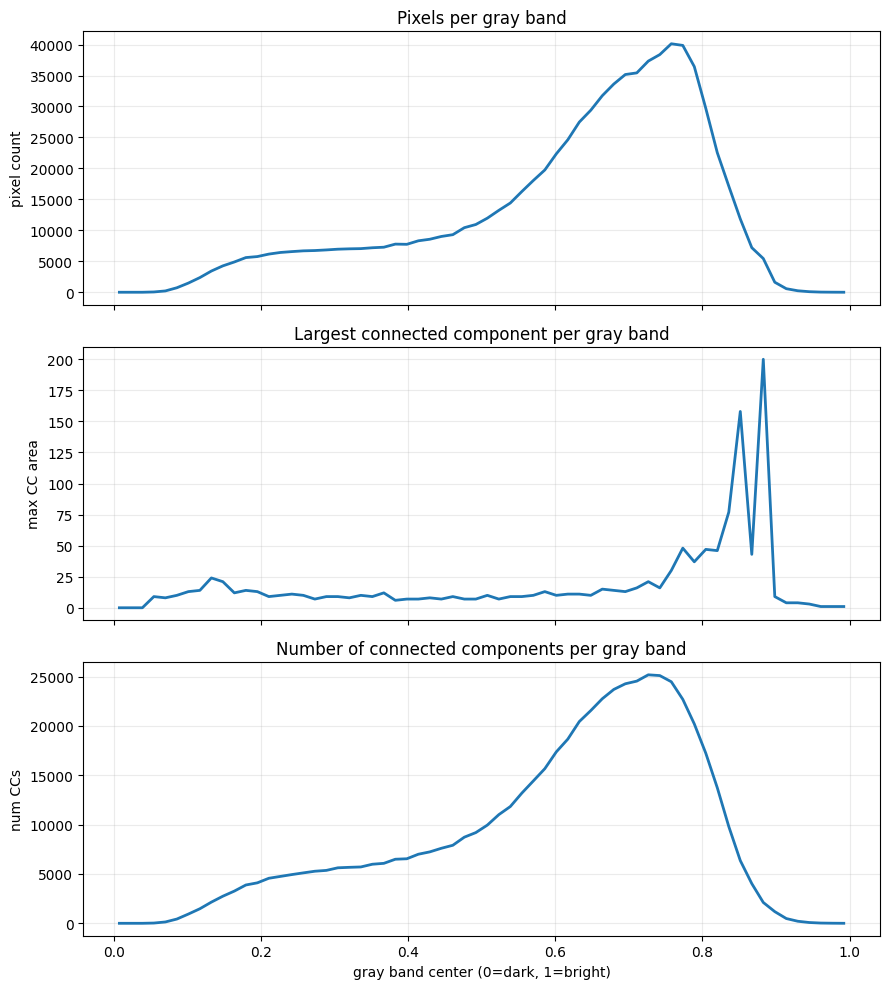

In [6]:
root = find_project_root(".")  
img = np.asarray(Image.open(root / "pictures" / "pictures_in" / "235761_1.tif"))
gray = to_gray_luminance(img)
centers, edges, pixel_counts, max_cc_areas, num_ccs = plot_band_stats(gray, n_bins=64)

In [7]:
def merged_band_mask(gray: np.ndarray, edges: np.ndarray, left_idx: int, right_idx: int):
    lo = edges[left_idx]
    hi = edges[right_idx + 1]
    return (gray >= lo) & (gray < hi)

def merged_band_stats(gray: np.ndarray, edges: np.ndarray, left_idx: int, right_idx: int, connectivity: int = 2):
    band = merged_band_mask(gray, edges, left_idx, right_idx)
    pixel_count = int(band.sum())

    lab = label(band, connectivity=connectivity)
    props = regionprops(lab)
    areas = [r.area for r in props]

    max_cc_area = max(areas) if areas else 0
    num_cc = len(areas)

    return {
        "left_idx": left_idx,
        "right_idx": right_idx,
        "lo": edges[left_idx],
        "hi": edges[right_idx + 1],
        "pixel_count": pixel_count,
        "max_cc_area": max_cc_area,
        "num_cc": num_cc,
        "mask": band,
    }

def grow_from_peak(gray: np.ndarray, edges: np.ndarray, peak_idx: int, max_steps: int = 10):
    results = []
    n_bins = len(edges) - 1

    left = right = peak_idx
    results.append(merged_band_stats(gray, edges, left, right))

    for _ in range(max_steps):
        candidates = []

        if left > 0:
            candidates.append((left - 1, right))
        if right < n_bins - 1:
            candidates.append((left, right + 1))
        if left > 0 and right < n_bins - 1:
            candidates.append((left - 1, right + 1))

        if not candidates:
            break

        # 选择 max_cc_area 最大的扩展方案
        cand_stats = [merged_band_stats(gray, edges, l, r) for l, r in candidates]
        best = max(cand_stats, key=lambda d: d["max_cc_area"])

        left, right = best["left_idx"], best["right_idx"]
        results.append(best)

    return results

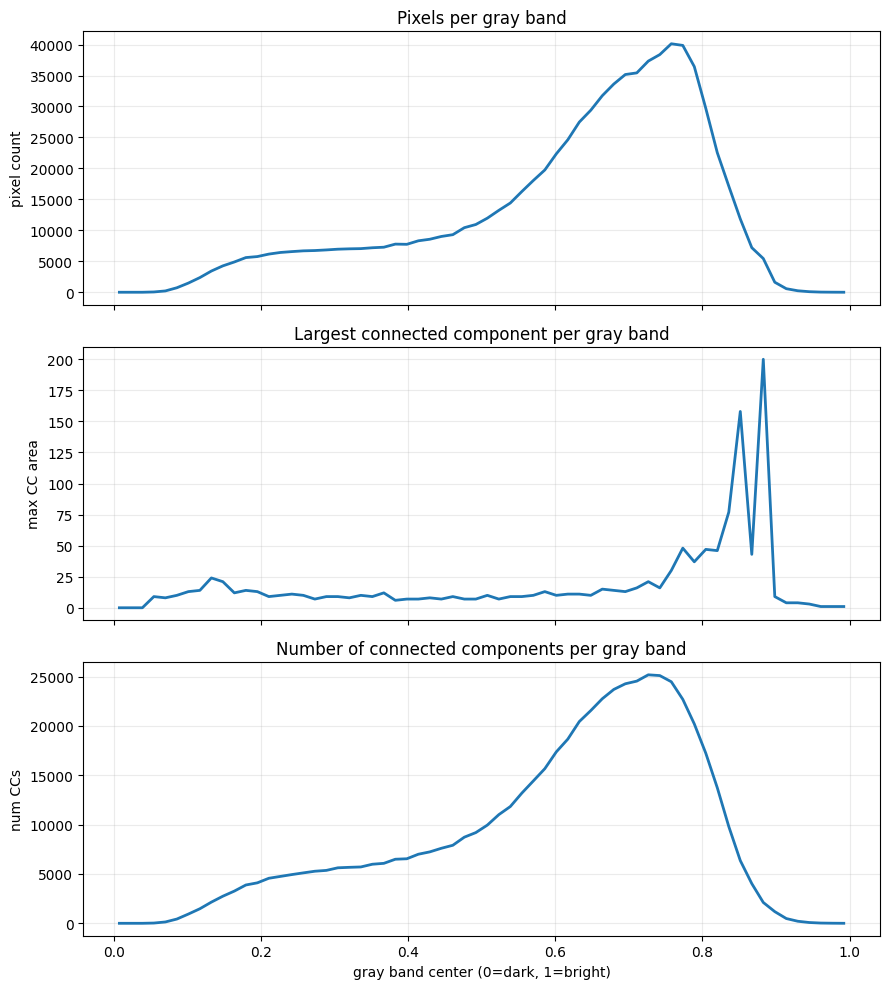

[0.875, 0.891)  pixels=5443  max_cc=200.0  num_cc=2111
0.03674444240308653
[0.859, 0.906)  pixels=14256  max_cc=289.0  num_cc=4806
0.02027216610549944
[0.844, 0.922)  pixels=26669  max_cc=321.0  num_cc=7778
0.012036446810904046
[0.828, 0.938)  pixels=44039  max_cc=1698.0  num_cc=11344
0.038556733804128156
[0.812, 0.953)  pixels=66665  max_cc=6171.0  num_cc=14563
0.09256731418285458
[0.797, 0.969)  pixels=96383  max_cc=9975.0  num_cc=15867
0.10349335463722856
[0.781, 0.969)  pixels=132824  max_cc=34521.0  num_cc=15733
0.2599003192194182
[0.766, 0.969)  pixels=172687  max_cc=100937.0  num_cc=16213
0.5845083880083619
[0.750, 0.969)  pixels=212817  max_cc=135310.0  num_cc=16707
0.6358044705075252
[0.734, 0.969)  pixels=251198  max_cc=158192.0  num_cc=16302
0.6297502368649432
[0.719, 0.969)  pixels=288529  max_cc=177845.0  num_cc=14788
0.61638518138558
[0.703, 0.969)  pixels=323955  max_cc=197300.0  num_cc=12641
0.6090352055069377
[0.688, 0.969)  pixels=359116  max_cc=217479.0  num_cc=10184

In [21]:
root = find_project_root(".")  
img = np.asarray(Image.open(root / "pictures" / "pictures_in" / "235761_1.tif"))
gray = to_gray_luminance(img)
centers, edges, pixel_counts, max_cc_areas, num_ccs = plot_band_stats(gray, n_bins=64)
peak_idx = np.argmax(max_cc_areas)
results = grow_from_peak(gray, edges, peak_idx, max_steps=12)

for r in results:
    m = r["max_cc_area"] / r["pixel_count"]
    print(
        f"[{r['lo']:.3f}, {r['hi']:.3f})  "
        f"pixels={r['pixel_count']}  "
        f"max_cc={r['max_cc_area']}  "
        f"num_cc={r['num_cc']}"
    )
    print(m)

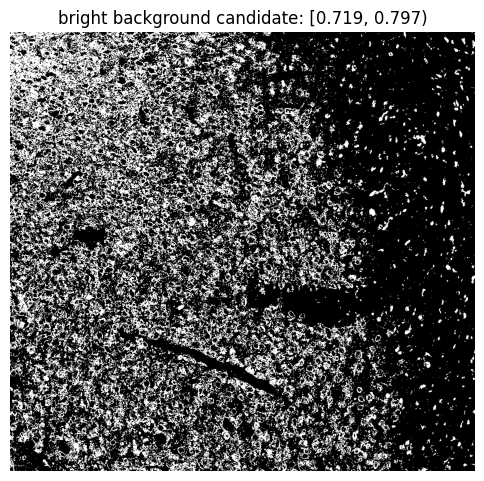

In [25]:
bright_bg = (gray >= 0.288) & (gray <= 0.6)

plt.figure(figsize=(6,6))
plt.imshow(bright_bg, cmap="gray")
plt.title("bright background candidate: [0.719, 0.797)")
plt.axis("off")
plt.show()